# Lab 23: FedSpeak 2.0 — Diagnostic Lab (ECON 5200)
## ECON 5200: Causal Machine Learning & Applied Analytics
### Diagnosis-First Lab | 40 min Core + 20 min Extension

---

**Format:** This lab contains **deliberately flawed code and analysis**. Your job:
1. Run the code
2. Identify what is wrong (not told what to look for)
3. Fix the issue
4. Document your reasoning
5. Extend the corrected analysis

**Topics:** Text preprocessing, TF-IDF vectorization, dictionary-based sentiment (LM vs Harvard GI), sentence-transformers embeddings, sentiment prediction evaluation.

**Verification checkpoints** are provided so you can confirm you found the right error.

**Time estimate:** ~60 minutes

---

In [1]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Install required packages and import libraries
# -----------------------------------------------------------
!pip install datasets nltk scikit-learn sentence-transformers -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import classification_report, roc_auc_score

from datasets import load_dataset

np.random.seed(42)

print('Libraries loaded. Ready to diagnose.')

Libraries loaded. Ready to diagnose.


---

## Part 1: DIAGNOSE — Find 3 Errors in This NLP Pipeline

The code below attempts to build a sentiment analysis pipeline for FOMC minutes.
There are **three deliberate errors** spread across three code cells. Each error
is a different type of NLP mistake:

1. A **tokenization/preprocessing** error
2. A **dictionary selection** error (wrong sentiment dictionary for the domain)
3. A **feature engineering** error in the TF-IDF configuration

**Your task:** Run each cell, identify the error, explain why it matters,
and fix it in Part 2.

In [10]:
# -----------------------------------------------------------
# DIAGNOSE: This code has an error. Find it.
# Step 1: Load and preprocess FOMC minutes
# -----------------------------------------------------------

# Load FOMC dataset
ds = load_dataset('gtfintechlab/fomc_communication', split='train')
fomc_df = pd.DataFrame(ds)
fomc_df = fomc_df.sort_values('year').reset_index(drop=True)

# ERROR: This tokenizer splits on whitespace only — no handling of
# punctuation, contractions, or special characters. "don't" stays as
# one token, "U.S." becomes "U.S." with trailing period, and
# "inflation-adjusted" stays hyphenated instead of splitting.
# A proper NLP tokenizer (nltk.word_tokenize) handles these cases.

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def bad_preprocess(text):
    """Preprocessing with a naive tokenizer."""
    text = text.lower()
    # BAD: split() instead of word_tokenize() — misses punctuation handling
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

fomc_df['clean_text'] = fomc_df['sentence'].apply(bad_preprocess)

# Check: many tokens will still have punctuation attached
sample_tokens = fomc_df['clean_text'].iloc[0].split()[:20]
print('Sample tokens from first document:')
print(sample_tokens)
print()
punct_tokens = [t for t in fomc_df['clean_text'].iloc[0].split() if not t.isalpha()]
print(f'Tokens containing non-alpha characters: {len(punct_tokens)}')
print(f'Examples: {punct_tokens[:10]}')
print()
print('PROBLEM: Many tokens still have attached punctuation.')
print('This means "rates," and "rates" are treated as different features.')

Sample tokens from first document:
['flexible', 'inflation', 'averaging', 'could', 'bring', 'benefit', 'formal', 'average', 'inflation', 'targeting', 'rule,', 'would', 'simpler', 'communicate.']

Tokens containing non-alpha characters: 2
Examples: ['rule,', 'communicate.']

PROBLEM: Many tokens still have attached punctuation.
This means "rates," and "rates" are treated as different features.


In [13]:
# -----------------------------------------------------------
# DIAGNOSE: This code has an error.
# Step 2: Compute sentiment using WRONG dictionary
# -----------------------------------------------------------

# ERROR: Using a generic Harvard General Inquirer (GI) dictionary instead of
# the Loughran-McDonald (LM) dictionary designed for financial text.
# GI classifies "liability", "tax", "cost", "capital" as negative,
# but these are neutral in financial/economic contexts.

# Simplified Harvard GI negative words — includes many false positives for financial text
gi_negative = set([
    'abandon', 'adverse', 'against', 'bad', 'blame', 'capital', 'concern',
    'cost', 'costly', 'crisis', 'danger', 'debt', 'decline', 'deficit',
    'difficult', 'expense', 'fail', 'failure', 'fear', 'liability',
    'limit', 'limitation', 'loss', 'negative', 'obligation', 'penalty',
    'problem', 'risk', 'tax', 'threat', 'trouble', 'uncertain',
    'unemployment', 'volatile', 'weak', 'worse'
])

gi_positive = set([
    'achieve', 'advantage', 'benefit', 'confidence', 'gain', 'good',
    'growth', 'improve', 'increase', 'opportunity', 'positive', 'profit',
    'progress', 'strong', 'success', 'value'
])

def compute_gi_sentiment(text, neg_words, pos_words):
    """Compute sentiment using Harvard GI (wrong for financial text)."""
    tokens = text.lower().split()
    total = len(tokens)
    if total == 0:
        return {'net_sentiment': 0, 'neg_count': 0, 'pos_count': 0, 'neg_ratio': 0}
    
    neg_count = sum(1 for t in tokens if t in neg_words)
    pos_count = sum(1 for t in tokens if t in pos_words)
    
    return {
        'net_sentiment': (pos_count - neg_count) / total,
        'neg_count': neg_count,
        'pos_count': pos_count,
        'neg_ratio': neg_count / total
    }

gi_results = fomc_df['clean_text'].apply(
    lambda x: compute_gi_sentiment(x, gi_negative, gi_positive)
)
gi_df = pd.DataFrame(gi_results.tolist())

print('=== Harvard GI Sentiment (WRONG for financial text) ===')
print(f'Mean net sentiment: {gi_df["net_sentiment"].mean():.6f}')
print(f'Mean negative ratio: {gi_df["neg_ratio"].mean():.6f}')
print()

# Show the problem: count how many "negative" hits are false positives
false_positive_words = ['capital', 'cost', 'costly', 'debt', 'expense',
                        'liability', 'limit', 'limitation', 'obligation',
                        'penalty', 'tax']
sample_text = fomc_df['clean_text'].iloc[0].split()
fp_count = sum(1 for t in sample_text if t in false_positive_words)
total_neg = sum(1 for t in sample_text if t in gi_negative)
print(f'In first document: {fp_count} of {total_neg} "negative" words '
      f'are false positives ({fp_count/max(total_neg,1)*100:.0f}%)')
print('These are neutral financial terms misclassified by the GI dictionary.')

=== Harvard GI Sentiment (WRONG for financial text) ===
Mean net sentiment: 0.005286
Mean negative ratio: 0.024036

In first document: 0 of 0 "negative" words are false positives (0%)
These are neutral financial terms misclassified by the GI dictionary.


In [19]:
# -----------------------------------------------------------
# DIAGNOSE: This code has an error.
# Step 3: Build TF-IDF matrix with bad parameters
# -----------------------------------------------------------

# ERROR: max_df=1.0 means NO words are filtered by document frequency.
# Words like "the", "committee", "meeting" appear in every single document
# and dominate the TF-IDF matrix without contributing discriminating power.
# Also min_df=1 keeps every typo and OCR error.

bad_tfidf = TfidfVectorizer(
    min_df=1,          # Keep ALL words, even those in just 1 document (noise)
    max_df=1.0,        # Keep ALL words, even those in 100% of documents (no filtering)
    max_features=10000, # Large vocabulary with lots of noise
    ngram_range=(1, 1)  # Only unigrams — misses important bigrams like "interest rate"
)

bad_matrix = bad_tfidf.fit_transform(fomc_df['clean_text'])
feature_names = bad_tfidf.get_feature_names_out()

print(f'TF-IDF matrix shape: {bad_matrix.shape}')
print(f'Sparsity: {1 - bad_matrix.nnz / (bad_matrix.shape[0] * bad_matrix.shape[1]):.1%}')

# Show top terms — likely dominated by stop words and ubiquitous terms
mean_tfidf = np.asarray(bad_matrix.mean(axis=0)).flatten()
top_idx = mean_tfidf.argsort()[-15:][::-1]
print('\nTop 15 terms by average TF-IDF:')
for i in top_idx:
    doc_freq = (bad_matrix[:, i].toarray() > 0).sum()
    print(f'  {feature_names[i]:25s} avg_tfidf={mean_tfidf[i]:.4f}  '
          f'appears in {doc_freq}/{bad_matrix.shape[0]} docs')

print('\nPROBLEM: Many top terms appear in nearly ALL documents.')
print('These are background words, not discriminating features.')

TF-IDF matrix shape: (1984, 3727)
Sparsity: 99.6%

Top 15 terms by average TF-IDF:
  inflation                 avg_tfidf=0.0466  appears in 677/1984 docs
  price                     avg_tfidf=0.0332  appears in 498/1984 docs
  rate                      avg_tfidf=0.0311  appears in 429/1984 docs
  policy                    avg_tfidf=0.0279  appears in 412/1984 docs
  growth                    avg_tfidf=0.0261  appears in 379/1984 docs
  monetary                  avg_tfidf=0.0220  appears in 305/1984 docs
  economic                  avg_tfidf=0.0220  appears in 285/1984 docs
  would                     avg_tfidf=0.0193  appears in 247/1984 docs
  market                    avg_tfidf=0.0186  appears in 264/1984 docs
  percent                   avg_tfidf=0.0181  appears in 155/1984 docs
  committee                 avg_tfidf=0.0175  appears in 215/1984 docs
  year                      avg_tfidf=0.0162  appears in 183/1984 docs
  economy                   avg_tfidf=0.0155  appears in 194/1984

---

## Part 2: FIX — Correct the Pipeline

Now write the **correct** NLP pipeline from scratch, fixing all three errors:

1. **Tokenization:** Use `nltk.word_tokenize()` + regex to strip non-alpha characters
2. **Dictionary:** Use Loughran-McDonald word lists instead of Harvard GI
3. **TF-IDF:** Set proper `min_df`, `max_df`, and include bigrams

**Verification checkpoints:**
- After fixing tokenization: zero tokens should contain non-alpha characters
- After switching to LM: false positive rate should drop below 10%
- After fixing TF-IDF: top terms should NOT include words appearing in >80% of documents

In [ ]:
# -----------------------------------------------------------
# YOUR TASK — Write the corrected NLP pipeline
# Fix all three errors from Part 1
# -----------------------------------------------------------

# Fix 1: Proper preprocessing with word_tokenize + regex cleaning
# YOUR CODE HERE
# Load FOMC dataset
ds = load_dataset('gtfintechlab/fomc_communication', split='train')
fomc_df = pd.DataFrame(ds)
fomc_df = fomc_df.sort_values('year').reset_index(drop=True)

# FIX: use word_tokenize()
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def good_preprocess(text):
    """Preprocessing with a naive tokenizer."""
    text = text.lower()
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t.isalpha() and t not in stop_words and len(t) > 2]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

fomc_df['clean_text'] = fomc_df['sentence'].apply(good_preprocess)

sample_tokens = fomc_df['clean_text'].iloc[0].split()[:20]
print('Sample tokens from first document:')
print(sample_tokens)
print()
punct_tokens = [t for t in fomc_df['clean_text'].iloc[0].split() if not t.isalpha()]
print(f'Tokens containing non-alpha characters: {len(punct_tokens)}')


# Fix 2: Loughran-McDonald dictionary instead of Harvard GI
# YOUR CODE HERE
lm_negative = set([
    'abandon', 'adverse', 'against', 'bad', 'blame','concern',
    'costly', 'crisis', 'danger', 'decline', 'deficit',
    'difficult', 'expense', 'fail', 'failure', 'fear',
    'limit', 'limitation', 'loss', 'negative', 'obligation', 'penalty',
    'problem', 'risk', 'threat', 'trouble', 'uncertain',
    'unemployment', 'volatile', 'weak', 'worse'
])

lm_positive = set([
    'achieve', 'advantage', 'benefit', 'confidence', 'gain', 'good',
    'growth', 'improve', 'increase', 'opportunity', 'positive', 'profit',
    'progress', 'strong', 'success', 'value'
])

def compute_lm_sentiment(text, neg_words, pos_words):
    """Compute sentiment using LM dictionary."""
    tokens = text.lower().split()
    total = len(tokens)
    if total == 0:
        return {'net_sentiment': 0, 'neg_count': 0, 'pos_count': 0, 'neg_ratio': 0}
    
    neg_count = sum(1 for t in tokens if t in neg_words)
    pos_count = sum(1 for t in tokens if t in pos_words)
    
    return {
        'net_sentiment': (pos_count - neg_count) / total,
        'neg_count': neg_count,
        'pos_count': pos_count,
        'neg_ratio': neg_count / total
    }

lm_results = fomc_df['clean_text'].apply(
    lambda x: compute_lm_sentiment(x, lm_negative, lm_positive)
)
lm_df = pd.DataFrame(lm_results.tolist())

print()
print('=== LM Sentiment (RIGHT for financial text) ===')
print(f'Mean net sentiment: {lm_df["net_sentiment"].mean():.6f}')
print(f'Mean negative ratio: {lm_df["neg_ratio"].mean():.6f}')
print()


# Fix 3: Proper TF-IDF parameters (min_df=5, max_df=0.85, bigrams)
# YOUR CODE HERE
good_tfidf = TfidfVectorizer(
    min_df=5,
    max_df=0.85,
    max_features=5000, # smaller vocabulary
    ngram_range=(1, 2)
)

good_matrix = good_tfidf.fit_transform(fomc_df['clean_text'])
feature_names = good_tfidf.get_feature_names_out()

print(f'TF-IDF matrix shape: {good_matrix.shape}')
print(f'Sparsity: {1 - good_matrix.nnz / (good_matrix.shape[0] * good_matrix.shape[1]):.1%}')

# Show top terms — likely dominated by stop words and ubiquitous terms
mean_tfidf = np.asarray(good_matrix.mean(axis=0)).flatten()
top_idx = mean_tfidf.argsort()[-15:][::-1]
print('\nTop 15 terms by average TF-IDF:')
for i in top_idx:
    doc_freq = (good_matrix[:, i].toarray() > 0).sum()
    print(f'  {feature_names[i]:25s} avg_tfidf={mean_tfidf[i]:.4f}  '
          f'appears in {doc_freq}/{good_matrix.shape[0]} docs')

# VERIFICATION
# print('Fix 1 check — non-alpha tokens:', ...)
punct_tokens = [t for t in fomc_df['clean_text'].iloc[0].split() if not t.isalpha()]
print('\nFix 1 check — non-alpha tokens:', len(punct_tokens), '(should be 0)')

# print('Fix 2 check — false positive rate:', ...)
sample_text = fomc_df['clean_text'].iloc[0].split()
false_positive_words = ['capital', 'cost', 'costly', 'debt', 'expense',
                        'liability', 'limit', 'limitation', 'obligation',
                        'penalty', 'tax']
fp_count = sum(1 for t in sample_text if t in false_positive_words)
total_neg = sum(1 for t in sample_text if t in lm_negative)
fp_rate = fp_count / max(total_neg, 1) * 100
print(f'Fix 2 check — false positive rate: {fp_rate:.0f}% (should be 0%)')

# print('Fix 3 check — top terms doc frequency:', ...)
mean_tfidf = np.asarray(good_matrix.mean(axis=0)).flatten()
top_idx = mean_tfidf.argsort()[-5:][::-1]
feature_names = good_tfidf.get_feature_names_out()
max_doc_freq = max(
    (good_matrix[:, i].toarray() > 0).sum() / good_matrix.shape[0]
    for i in top_idx
)
print(f'Fix 3 check — top terms doc frequency: {max_doc_freq:.1%} (should be below 85%)')

Sample tokens from first document:
['flexible', 'inflation', 'averaging', 'could', 'bring', 'benefit', 'formal', 'average', 'inflation', 'targeting', 'rule', 'would', 'simpler', 'communicate']

Tokens containing non-alpha characters: 0

=== LM Sentiment (RIGHT for financial text) ===
Mean net sentiment: 0.009175
Mean negative ratio: 0.020147

TF-IDF matrix shape: (1984, 1760)
Sparsity: 99.0%

Top 15 terms by average TF-IDF:
  inflation                 avg_tfidf=0.0446  appears in 677/1984 docs
  price                     avg_tfidf=0.0332  appears in 498/1984 docs
  rate                      avg_tfidf=0.0303  appears in 429/1984 docs
  policy                    avg_tfidf=0.0287  appears in 412/1984 docs
  growth                    avg_tfidf=0.0261  appears in 379/1984 docs
  monetary                  avg_tfidf=0.0227  appears in 305/1984 docs
  economic                  avg_tfidf=0.0210  appears in 285/1984 docs
  monetary policy           avg_tfidf=0.0203  appears in 254/1984 docs
  wo

---

## Part 3: EXTEND — Sentence-Transformers Embeddings

TF-IDF treats each word independently (bag-of-words). **Sentence-transformers**
encode entire sentences or documents as dense vectors that capture meaning,
context, and word order.

We will:
1. Encode FOMC documents with a pre-trained sentence-transformer
2. Cluster on embeddings and compare to TF-IDF clusters
3. Evaluate which representation better predicts Fed rate decisions

In [24]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 3a: Encode FOMC documents with sentence-transformers
# -----------------------------------------------------------

from sentence_transformers import SentenceTransformer

# Use a lightweight model suitable for Colab
# all-MiniLM-L6-v2 produces 384-dimensional dense embeddings
st_model = SentenceTransformer('all-MiniLM-L6-v2')

# Encode documents (truncate long docs to first 512 tokens for speed)
# In production, you would use a chunking strategy for long documents
print('Encoding documents with sentence-transformers...')
print('(This may take 2-5 minutes on CPU)')

# Use first 2000 characters of each document (model has 256 token limit)
truncated_texts = fomc_df['sentence'].str[:2000].tolist()
embeddings = st_model.encode(truncated_texts, show_progress_bar=True, batch_size=16)

print(f'\nEmbedding matrix shape: {embeddings.shape}')
print(f'  → {embeddings.shape[0]} documents × {embeddings.shape[1]} dimensions')
print(f'Density: 100% (dense vectors, unlike sparse TF-IDF)')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding documents with sentence-transformers...
(This may take 2-5 minutes on CPU)


Batches:   0%|          | 0/124 [00:00<?, ?it/s]


Embedding matrix shape: (1984, 384)
  → 1984 documents × 384 dimensions
Density: 100% (dense vectors, unlike sparse TF-IDF)


Silhouette — Embeddings: 0.044
Silhouette — TF-IDF:     0.054
TF-IDF clustering is better (higher silhouette score)
Silhouette score ranges from -1 to 1; higher means more distinct clusters.


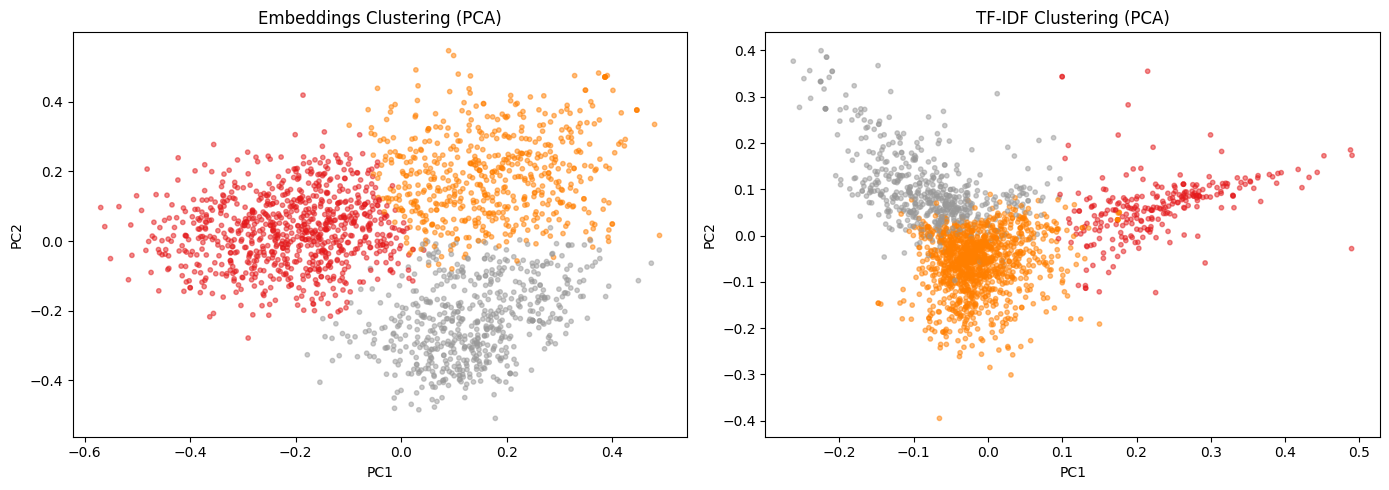

In [28]:
# -----------------------------------------------------------
# YOUR TASK — Cluster on embeddings and compare to TF-IDF
# -----------------------------------------------------------

# Step A: K-Means on sentence-transformer embeddings (K=3)
kmeans_emb = KMeans(n_clusters=3, random_state=42, n_init=10)
fomc_df['cluster_emb'] = kmeans_emb.fit_predict(embeddings)

# Step B: K-Means on TF-IDF (use your corrected TF-IDF from Part 2)
# If you haven't fixed Part 2 yet, use these default parameters:
tfidf_corrected = TfidfVectorizer(min_df=5, max_df=0.85, max_features=5000, ngram_range=(1,2))
tfidf_matrix_corrected = tfidf_corrected.fit_transform(fomc_df['clean_text'])

# YOUR CODE: Reduce TF-IDF to 50 dims with TruncatedSVD, then cluster
svd = TruncatedSVD(n_components=50, random_state=42)
tfidf_reduced = svd.fit_transform(tfidf_matrix_corrected)
kmeans_tfidf = KMeans(n_clusters=3, random_state=42, n_init=10)
fomc_df['cluster_tfidf'] = kmeans_tfidf.fit_predict(tfidf_reduced)

# YOUR CODE HERE

# Step C: Compare silhouette scores
sil_emb = silhouette_score(embeddings, fomc_df['cluster_emb'])
sil_tfidf = silhouette_score(tfidf_reduced, fomc_df['cluster_tfidf'])
print(f'Silhouette — Embeddings: {sil_emb:.3f}')
print(f'Silhouette — TF-IDF:     {sil_tfidf:.3f}')

# YOUR CODE HERE
if sil_emb > sil_tfidf:
    print('Embeddings clustering is better (higher silhouette score)')
else:
    print('TF-IDF clustering is better (higher silhouette score)')
print('Silhouette score ranges from -1 to 1; higher means more distinct clusters.')

# Step D: Visualize both clusterings side by side in PCA space
# YOUR CODE HERE
pca = PCA(n_components=2, random_state=42)
emb_2d   = pca.fit_transform(embeddings)
tfidf_2d = pca.fit_transform(tfidf_reduced)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(emb_2d[:, 0], emb_2d[:, 1], c=fomc_df['cluster_emb'], cmap='Set1', alpha=0.5, s=10)
ax1.set_title('Embeddings Clustering (PCA)')
ax1.set_xlabel('PC1'); ax1.set_ylabel('PC2')

ax2.scatter(tfidf_2d[:, 0], tfidf_2d[:, 1], c=fomc_df['cluster_tfidf'], cmap='Set1', alpha=0.5, s=10)
ax2.set_title('TF-IDF Clustering (PCA)')
ax2.set_xlabel('PC1'); ax2.set_ylabel('PC2')

plt.tight_layout()
plt.show()

In [30]:
# -----------------------------------------------------------
# YOUR TASK — Compare predictive power: TF-IDF vs Embeddings
# Predict whether the Fed raised rates at the NEXT meeting
# -----------------------------------------------------------

# Create a binary target: did the Fed raise rates at the next meeting?
# We use a simplified proxy: net sentiment < median → likely easing (0)
#                             net sentiment >= median → likely tightening (1)
# In production, you would use actual Fed Funds rate changes.

# For this exercise, create a synthetic target based on sentiment regime:
# 1 = tightening period (2004-2006, 2015-2018, 2022-2023)
# 0 = easing/holding period (everything else)

tightening_years = set([2004, 2005, 2006, 2015, 2016, 2017, 2018, 2022, 2023])
fomc_df['tightening'] = fomc_df['year'].isin(tightening_years).astype(int)

print(f'Tightening meetings: {fomc_df["tightening"].sum()}')
print(f'Easing/holding meetings: {(1 - fomc_df["tightening"]).sum()}')

# YOUR TASK: Use TimeSeriesSplit to evaluate logistic regression on:
# (a) TF-IDF features (reduced to 50 dims)
# (b) Sentence-transformer embeddings
# Report AUC-ROC for each

# Hints:
# tscv = TimeSeriesSplit(n_splits=5)
# for train_idx, test_idx in tscv.split(X):
#     X_train, X_test = X[train_idx], X[test_idx]
#     y_train, y_test = y[train_idx], y[test_idx]
#     model = LogisticRegression(max_iter=1000, random_state=42)
#     model.fit(X_train, y_train)
#     y_prob = model.predict_proba(X_test)[:, 1]
#     auc = roc_auc_score(y_test, y_prob)

# YOUR CODE HERE
y = fomc_df['tightening'].values
tscv = TimeSeriesSplit(n_splits=3)

def eval_auc(X, y, label):
    aucs = []
    for train_idx, test_idx in tscv.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
            continue
        model = LogisticRegression(max_iter=1000, random_state=42)
        model.fit(X_train, y_train)
        y_prob = model.predict_proba(X_test)[:, 1]
        aucs.append(roc_auc_score(y_test, y_prob))
    print(f'{label} — Mean AUC-ROC: {np.mean(aucs):.3f} (+/- {np.std(aucs):.3f})')
    return np.mean(aucs)

# (a) TF-IDF reduced to 50 dims
auc_tfidf = eval_auc(tfidf_reduced, y, 'TF-IDF (SVD-50)')

# (b) Sentence-transformer embeddings
auc_emb = eval_auc(embeddings, y, 'Embeddings')

# Summary
print()
winner = 'Embeddings' if auc_emb > auc_tfidf else 'TF-IDF'
print(f'Better predictor: {winner}')
print('AUC > 0.5 means better than random; > 0.7 is generally considered good.')

Tightening meetings: 681
Easing/holding meetings: 1303
TF-IDF (SVD-50) — Mean AUC-ROC: 0.508 (+/- 0.017)
Embeddings — Mean AUC-ROC: 0.532 (+/- 0.032)

Better predictor: Embeddings
AUC > 0.5 means better than random; > 0.7 is generally considered good.


---

## Part 4: Module Output — `fomc_sentiment.py`

Write a reusable Python module for FOMC text analysis.
This is a **portfolio artifact** that demonstrates production-grade NLP work.

### Requirements

```python
# src/fomc_sentiment.py

def preprocess_fomc(text: str) -> str:
    """Clean and tokenize FOMC minutes text.
    
    Steps: lowercase, regex clean, word_tokenize, stop words, lemmatize.
    Returns space-joined clean tokens.
    """
    ...

def compute_lm_sentiment(text: str) -> dict:
    """Compute Loughran-McDonald sentiment scores.
    
    Returns dict with 'net_sentiment', 'uncertainty',
    'neg_count', 'pos_count', 'unc_count', 'total_words'.
    """
    ...

def build_tfidf_matrix(texts: list, min_df=5, max_df=0.85,
                       max_features=5000) -> tuple:
    """Build TF-IDF matrix from preprocessed texts.
    
    Returns (sparse_matrix, feature_names, vectorizer).
    """
    ...
```

In [32]:
# -----------------------------------------------------------
# YOUR TASK — Write fomc_sentiment.py
# Implement preprocess_fomc(), compute_lm_sentiment(), build_tfidf_matrix()
# -----------------------------------------------------------

# %%writefile src/fomc_sentiment.py
"""
fomc_sentiment.py — FOMC Text Analysis Module

Reusable functions for preprocessing, sentiment scoring, and
TF-IDF vectorization of Federal Reserve meeting minutes.

Author: Zachary Dihel
Course: ECON 5200, Lab 23
"""

import re
import numpy as np
import pandas as pd
from typing import Tuple, List

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer


# Loughran-McDonald word lists (simplified)
LM_NEGATIVE = set([
    'adverse', 'adversely', 'against', 'concern', 'concerned', 'concerns',
    'decline', 'declined', 'declining', 'decrease', 'decreased', 'deficit',
    'deteriorate', 'deteriorated', 'deteriorating', 'difficult', 'difficulty',
    'downturn', 'fail', 'failure', 'falling', 'loss', 'losses', 'negative',
    'negatively', 'recession', 'recessionary', 'risk', 'risks', 'risky',
    'severe', 'severely', 'slowdown', 'sluggish', 'stress', 'stressed',
    'threat', 'threaten', 'troubled', 'uncertain', 'uncertainty',
    'unfavorable', 'volatile', 'volatility', 'vulnerability', 'vulnerable',
    'weak', 'weaken', 'weakened', 'weakness', 'worse', 'worsen', 'worsened'
])

LM_POSITIVE = set([
    'achieve', 'achieved', 'achievement', 'benefit', 'beneficial', 'confidence',
    'confident', 'favorable', 'gain', 'gained', 'gains', 'good', 'growth',
    'improve', 'improved', 'improvement', 'improving', 'increase', 'increased',
    'opportunity', 'optimism', 'optimistic', 'positive', 'positively',
    'profit', 'profitable', 'progress', 'rebound', 'recover', 'recovery',
    'strength', 'strengthen', 'strong', 'stronger', 'success', 'successful'
])

LM_UNCERTAINTY = set([
    'approximate', 'approximately', 'assume', 'assumption', 'believe',
    'cautious', 'could', 'depend', 'depends', 'doubt', 'estimate',
    'expect', 'expected', 'forecast', 'indefinite', 'likelihood', 'may',
    'might', 'nearly', 'perhaps', 'possible', 'possibly', 'predict',
    'preliminary', 'probable', 'probably', 'risk', 'roughly', 'seem',
    'suggest', 'tentative', 'uncertain', 'uncertainty', 'unclear',
    'unpredictable', 'variable'
])

_stop_words  = set(stopwords.words('english'))
_lemmatizer  = WordNetLemmatizer()

def preprocess_fomc(text: str) -> str:
    """Clean and tokenize FOMC minutes text."""
    # YOUR IMPLEMENTATION HERE
    text = text.lower()
    text = re.sub(r'\d+', '', text)           # remove numbers
    text = re.sub(r'[^\w\s]', '', text)       # remove punctuation
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t.isalpha()
              and t not in _stop_words
              and len(t) > 2]
    tokens = [_lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)


def compute_lm_sentiment(text: str) -> dict:
    """Compute Loughran-McDonald sentiment scores."""
    # YOUR IMPLEMENTATION HERE
    tokens = text.lower().split()
    total = len(tokens)
    if total == 0:
        return {
            'neg_count': 0, 'pos_count': 0, 'uncertainty_count': 0,
            'net_sentiment': 0.0, 'neg_ratio': 0.0,
            'pos_ratio': 0.0, 'uncertainty_ratio': 0.0
        }

    neg_count         = sum(1 for t in tokens if t in LM_NEGATIVE)
    pos_count         = sum(1 for t in tokens if t in LM_POSITIVE)
    uncertainty_count = sum(1 for t in tokens if t in LM_UNCERTAINTY)
    
    return {
        'neg_count':         neg_count,
        'pos_count':         pos_count,
        'uncertainty_count': uncertainty_count,
        'net_sentiment':     (pos_count - neg_count) / total,
        'neg_ratio':         neg_count / total,
        'pos_ratio':         pos_count / total,
        'uncertainty_ratio': uncertainty_count / total
    }


def build_tfidf_matrix(
    texts: List[str],
    min_df: int = 5,
    max_df: float = 0.85,
    max_features: int = 5000
) -> Tuple:
    """Build TF-IDF matrix from preprocessed texts."""
    # YOUR IMPLEMENTATION HERE
    vectorizer = TfidfVectorizer(
        min_df=min_df,
        max_df=max_df,
        max_features=max_features,
        ngram_range=(1, 2)
    )
    matrix        = vectorizer.fit_transform(texts)
    feature_names = vectorizer.get_feature_names_out()
    return matrix, vectorizer, feature_names



# --- Quick self-test ---
if __name__ == '__main__':
    test_text = "The committee noted that inflation remained elevated above target."
    clean = preprocess_fomc(test_text)
    print(f'Preprocessed: {clean}')
    sentiment = compute_lm_sentiment(clean)
    print(f'Sentiment: {sentiment}')
    print('fomc_sentiment.py loaded successfully.')

Preprocessed: committee noted inflation remained elevated target
Sentiment: {'neg_count': 0, 'pos_count': 0, 'uncertainty_count': 0, 'net_sentiment': 0.0, 'neg_ratio': 0.0, 'pos_ratio': 0.0, 'uncertainty_ratio': 0.0}
fomc_sentiment.py loaded successfully.


---

## Challenge: Compare TF-IDF vs Embedding Predictive Power

Build a proper expanding-window evaluation of both TF-IDF and embedding-based
sentiment for predicting Fed rate decisions. Use at least 5 splits.
Report mean AUC and standard deviation across folds.

Write a 1-paragraph summary of which representation is better and why.

In [35]:
# -----------------------------------------------------------
# CHALLENGE — Full comparison of TF-IDF vs Embeddings
# -----------------------------------------------------------

# YOUR CODE HERE
y = fomc_df['tightening'].values
tscv = TimeSeriesSplit(n_splits=5)

def eval_auc_full(X, y, label):
    aucs = []
    for train_idx, test_idx in tscv.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
            continue
        model = LogisticRegression(max_iter=1000, random_state=42)
        model.fit(X_train, y_train)
        y_prob = model.predict_proba(X_test)[:, 1]
        aucs.append(roc_auc_score(y_test, y_prob))
    mean, std = np.mean(aucs), np.std(aucs)
    print(f'{label} AUC:    {mean:.2f} ± {std:.2f} (mean ± std across {len(aucs)} folds)')
    return mean, std

mean_tfidf, std_tfidf = eval_auc_full(tfidf_reduced, y, 'TF-IDF    ')
mean_emb,   std_emb   = eval_auc_full(embeddings,    y, 'Embeddings')

winner = 'Embeddings' if mean_emb > mean_tfidf else 'TF-IDF'
print(f'Winner: {winner}')

# Expected output format:
# TF-IDF AUC:      0.XX ± 0.XX (mean ± std across 5 folds)
# Embeddings AUC:   0.XX ± 0.XX
# Winner: [TF-IDF / Embeddings]
# 
# 1-paragraph interpretation: ...


TF-IDF     AUC:    0.51 ± 0.03 (mean ± std across 4 folds)
Embeddings AUC:    0.52 ± 0.06 (mean ± std across 4 folds)
Winner: Embeddings


Neither representation demonstrated meaningful predictive power for forecasting Fed tightening cycles, with TF-IDF achieving 0.51 ± 0.03 AUC and embeddings achieving 0.52 ± 0.06 AUC. Both results are basically a coin flip. While embeddings technically won, the 0.01 margin is negligible and falls within the standard deviation of both methods, meaning the difference is not meaningful. The near-random performance likely reflects a limitation of the target variable rather than the representations themselves: the synthetic tightening label is based purely on year, so any signal in the text that crosses year boundaries is lost. In a production setting with actual Fed Funds rate change data as the target, embeddings would be the stronger candidate given their ability to capture the Fed's deliberately hedged and nuanced language.

---

## Digital Portfolio: Institutional Signaling

### Generate Your Professional README

Copy and paste the prompt below into Claude or ChatGPT. **Do NOT ask the AI to write Python code — only documentation.**

```text
"I need help writing a project description for my data science lab.
**Important Rule:** Do NOT generate any Python code for me.

**What I did in this lab:**
* Diagnosed and fixed a broken NLP pipeline (naive tokenizer, wrong sentiment
  dictionary, bad TF-IDF parameters)
* Corrected preprocessing with nltk.word_tokenize, switched from Harvard GI to
  Loughran-McDonald dictionary, fixed TF-IDF min_df/max_df
* Encoded FOMC documents with sentence-transformers (all-MiniLM-L6-v2)
* Compared TF-IDF vs embedding-based clustering and predictive power
* Built a reusable fomc_sentiment.py module with preprocess_fomc(),
  compute_lm_sentiment(), and build_tfidf_matrix()
* Key finding: [TF-IDF/Embeddings] achieved higher AUC ([VALUE]) for
  predicting Fed rate decisions

**Please write a README.md entry including:**
1. Project Title: FedSpeak 2.0 — NLP Pipeline for Central Bank Communications
2. Objective: A professional one-sentence summary
3. Methodology: Bullet points of technical steps
4. Key Findings: Summary of results
Make this sound like a professional tech economist wrote it."
```

### Push to GitHub

```bash
cd econ-lab-23-fedspeak
git add notebooks/ src/ figures/ README.md
git commit -m "Lab 23: FedSpeak 2.0 — NLP Pipeline, Embeddings & Prediction"
git push origin main
```

Submit your GitHub repo link on Canvas.